<a href="https://colab.research.google.com/github/anushagottam1-anusha/Customer-Segmentation-Analysis/blob/main/Predictive_Analytics_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')

In [8]:
# Generate a time series with a trend, seasonality, and noise
dates = pd.date_range(start='2020-01-01', periods=365*3, freq='D') # 3 years of daily data

# Linear trend
trend = np.linspace(0, 100, len(dates))

# Seasonality (e.g., yearly cycle)
seasonality = 15 * np.sin(np.linspace(0, 3 * 2 * np.pi, len(dates))) + \
              5 * np.sin(np.linspace(0, 12 * 2 * np.pi, len(dates))) # Yearly and monthly component

# Random noise
np.random.seed(42)
noise = np.random.normal(0, 5, len(dates))

# Combine components to create the target variable 'value'
value = trend + seasonality + noise

df = pd.DataFrame({'Date': dates, 'Value': value})
df.set_index('Date', inplace=True)

display(df.head())

,Value
Date,
2020-01-01,2.483571
2020-01-02,0.002849
2020-01-03,4.625071
2020-01-04,9.690821
2020-01-05,1.588844


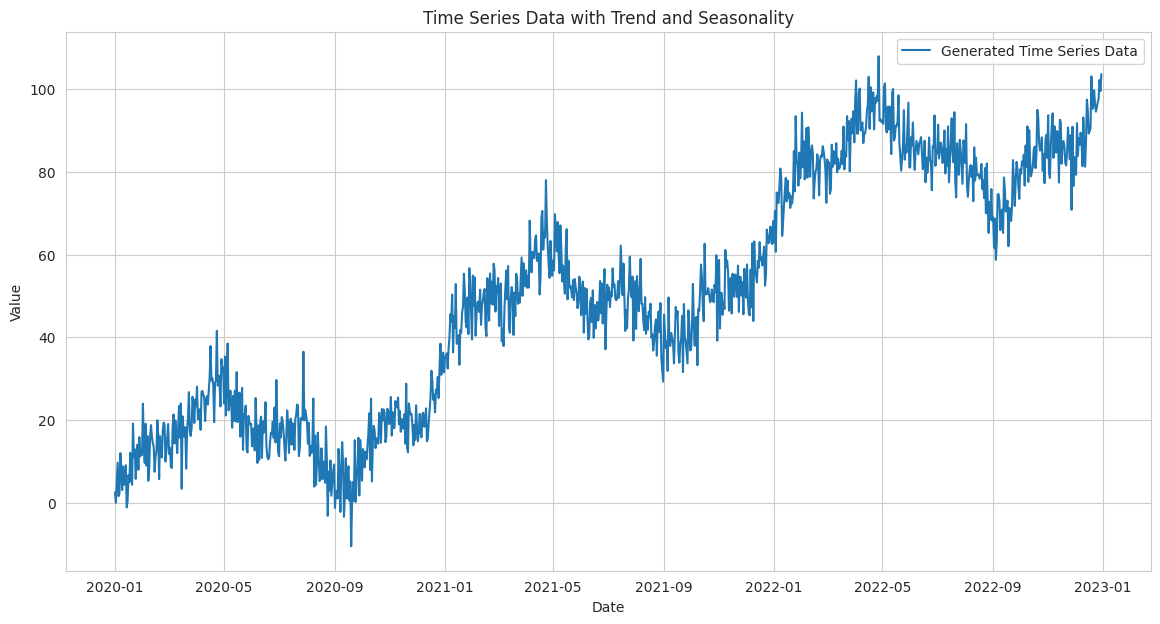

In [9]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Value'], label='Generated Time Series Data')
plt.title('Time Series Data with Trend and Seasonality')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

In [10]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['DayOfWeek'] = df.index.dayofweek
df['DayOfYear'] = df.index.dayofyear
df['WeekOfYear'] = df.index.isocalendar().week.astype(int)

# Lag features (e.g., value from the previous day/week)
df['Value_Lag1'] = df['Value'].shift(1)
df['Value_Lag7'] = df['Value'].shift(7)

# Rolling mean (e.g., average of the last 7 days)
df['RollingMean_7'] = df['Value'].rolling(window=7).mean()

# Drop rows with NaN values created by shifting/rolling
df.dropna(inplace=True)

display(df.head())

,Value,Year,Month,Day,DayOfWeek,DayOfYear,WeekOfYear,Value_Lag1,Value_Lag7,RollingMean_7
Date,,,,,,,,,,
2020-01-08,8.601491,2020,1,8,2,8,2,12.001613,2.483571,5.539541
2020-01-09,3.064164,2020,1,9,3,9,2,8.601491,0.002849,5.976872
2020-01-10,8.758507,2020,1,10,4,10,2,3.064164,4.625071,6.567363
2020-01-11,4.348302,2020,1,11,5,11,2,8.758507,9.690821,5.804146
2020-01-12,4.940565,2020,1,12,6,12,2,4.348302,1.588844,6.282963


In [11]:
# Define features (X) and target (y)
features = ['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'WeekOfYear', 'Value_Lag1', 'Value_Lag7', 'RollingMean_7']
X = df[features]
y = df['Value']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) # Keep time series order

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Model training complete.")

Model training complete.


Mean Squared Error: 18.94
R-squared: 0.70


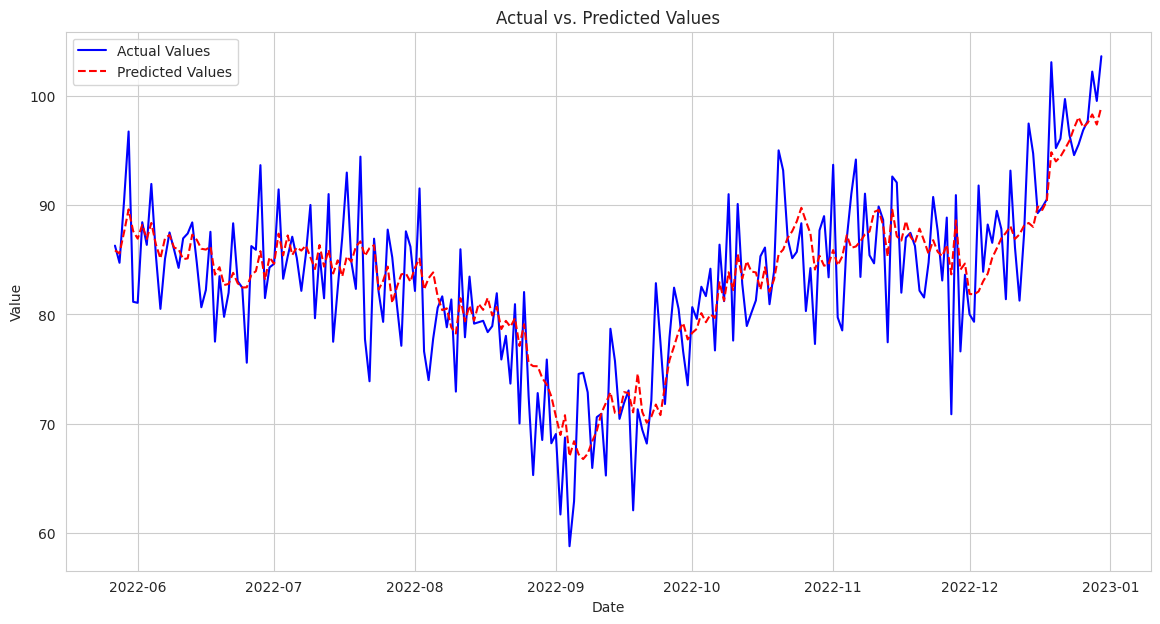

In [12]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

# Plot actual vs. predicted values
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Values', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted Values', color='red', linestyle='--')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()